In [1]:
# Libraries
import sys
sys.path.append("..")
from src.utils import section

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from src.data_load import data_loader

# Load data
df = data_loader("../data/raw/influencer_campaign_regression.csv")
df.head()

,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,avg_watch_time_sec,promo_discount_pct,content_format,audience_intent_tier,caption_word_count,hashtags_used_count,creator_phone_os,contract_payment_terms,posting_day_weather,campaign_revenue_usd
0,425.4,2.14,1331.0,35.2,10,Static-Carousel,High-Intent-Niche,35,16,Android,Net-30,Sunny,15192.26
1,171.3,5.73,3925.0,25.4,10,YouTube-Deep-Dive,Lifestyle-Warm,26,16,Android,Upfront,Cloudy,20018.44
2,356.4,8.03,1817.0,9.4,0,Short-Video-Reel,High-Intent-Niche,43,24,Android,Upfront,Cloudy,21146.87
3,272.2,7.70,942.0,32.1,15,Short-Video-Reel,Lifestyle-Warm,113,9,Android,Net-15,Rainy,17639.62
4,143.0,6.06,3347.0,51.0,20,Short-Video-Reel,Broad-Entertainment,72,18,Android,Net-30,Cloudy,17375.60


In [3]:
# Basic data exploration

# Shape of data
section("shape of data", 40)
print(f"Columns:             {df.shape[1]:,}\nRows:                {df.shape[0]:,}")

# Null values count
section("Null values", 40)
print(df.isnull().sum())

# Duplicate values
section("Duplicates", 40)
print(f"Number of duplicates:        {df.duplicated().sum()}")

# Basic info
section("Basic columns info", 40)
display(df.info())

# Statistical info
section("Statistical info", 40)
display(df.describe())

                                        
SHAPE OF DATA:
Columns:             13
Rows:                3,000
                                        
NULL VALUES:
creator_followers_k       0
engagement_rate_pct       0
paid_boost_spend_usd      0
avg_watch_time_sec        0
promo_discount_pct        0
content_format            0
audience_intent_tier      0
caption_word_count        0
hashtags_used_count       0
creator_phone_os          0
contract_payment_terms    0
posting_day_weather       0
campaign_revenue_usd      0
dtype: int64
                                        
DUPLICATES:
Number of duplicates:        0
                                        
BASIC COLUMNS INFO:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   creator_followers_k     3000 non-null   float64
 1   engagement_rate_pct     3000 non-null   float64
 2   paid

None

                                        
STATISTICAL INFO:


,creator_followers_k,engagement_rate_pct,paid_boost_spend_usd,avg_watch_time_sec,promo_discount_pct,caption_word_count,hashtags_used_count,campaign_revenue_usd
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,232.592433,5.161417,2317.529667,30.266467,12.358333,86.810000,12.367000,16678.699140
std,126.675186,2.539730,1273.365953,14.147323,8.613245,42.942674,6.996473,4747.136562
min,15.000000,0.800000,100.000000,6.100000,0.000000,12.000000,1.000000,2915.630000
25%,122.400000,2.927500,1208.750000,17.900000,5.000000,50.000000,6.000000,13222.897500
50%,229.800000,5.180000,2370.000000,30.400000,10.000000,86.000000,13.000000,16480.745000
75%,343.725000,7.410000,3416.250000,42.700000,20.000000,124.000000,18.000000,19839.157500
max,449.900000,9.500000,4499.000000,55.000000,25.000000,159.000000,24.000000,32527.890000


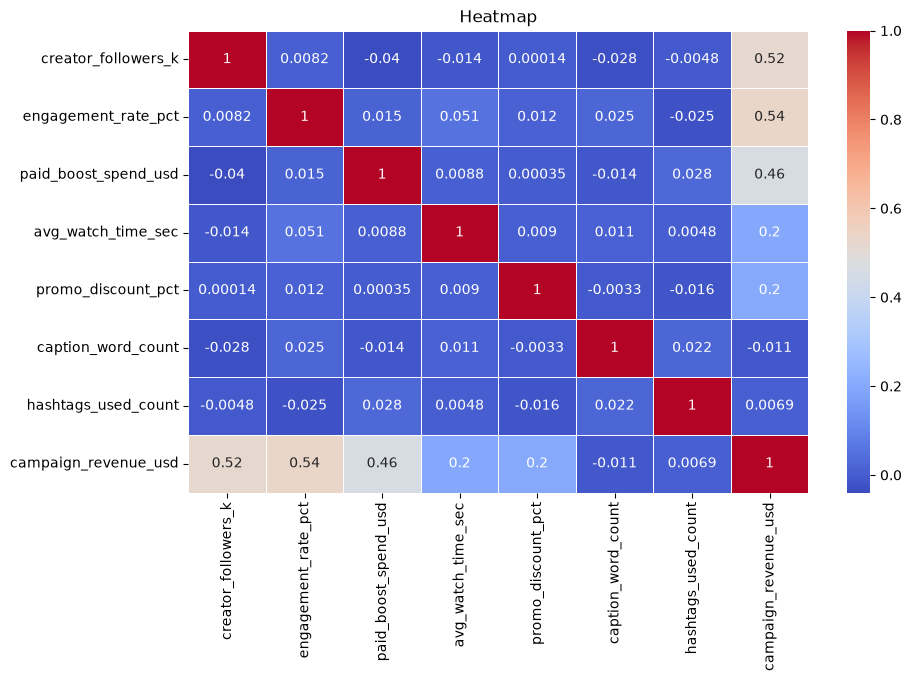

In [6]:
# Heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linecolor='white',
    linewidths=0.5
)
plt.title("Heatmap")
plt.savefig(f"../figures/corelation/regression_corelation-matrix.png", dpi=600, bbox_inches='tight')
plt.show()

                                                                                     
OUTLIERS DETECTION:


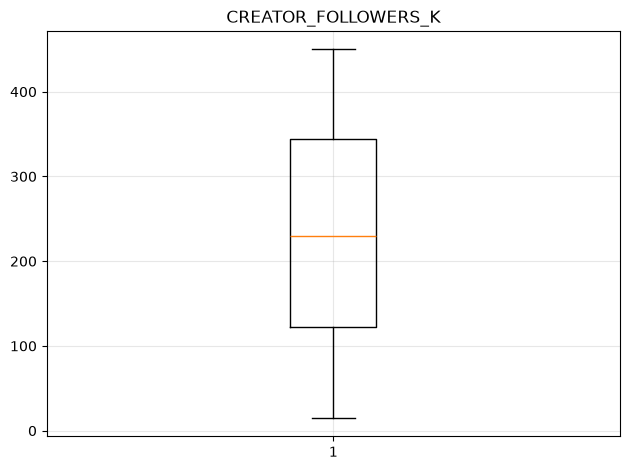

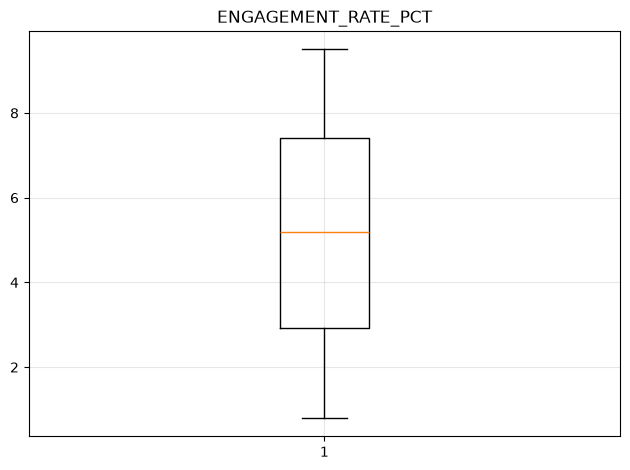

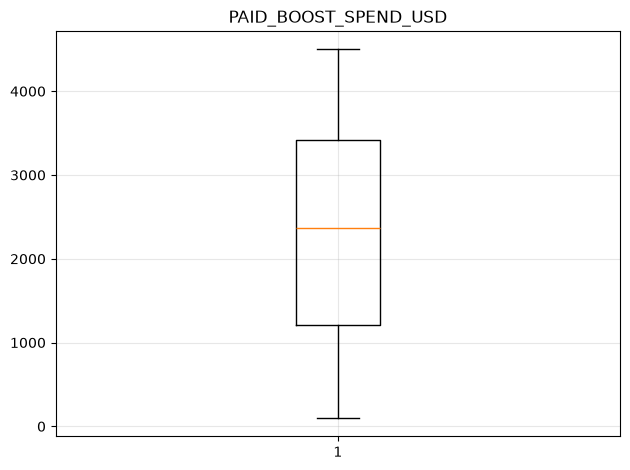

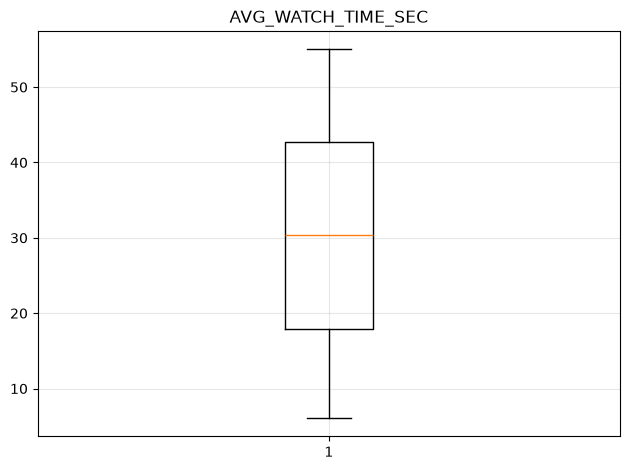

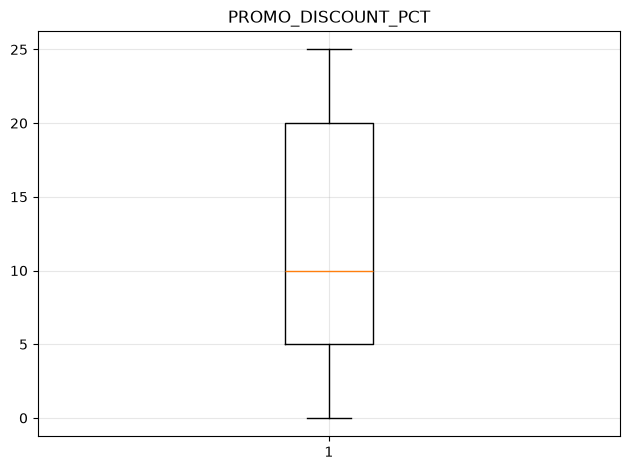

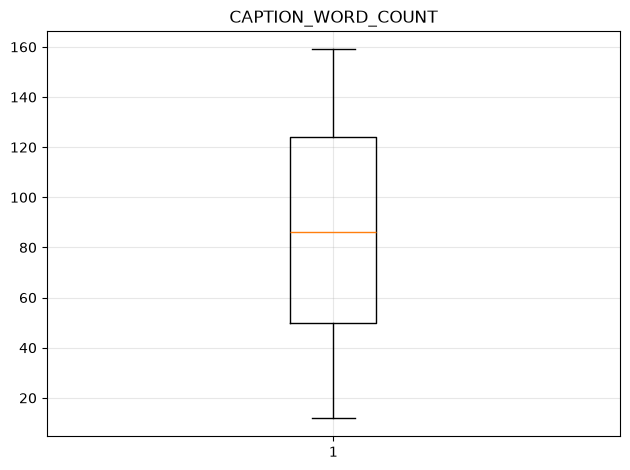

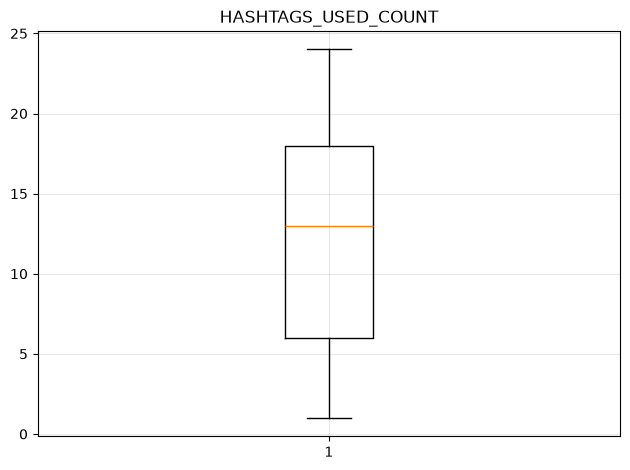

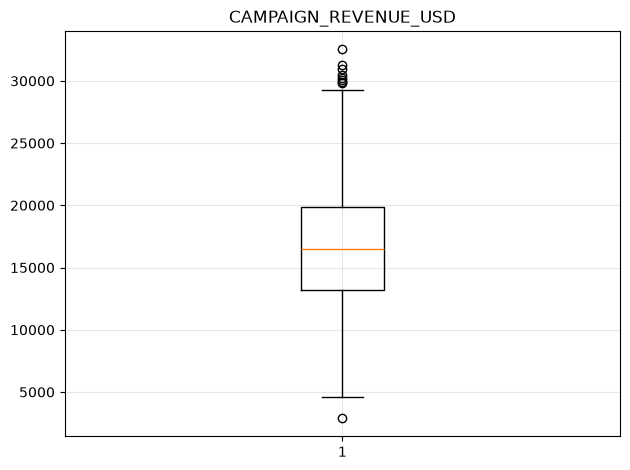

In [7]:
# Outliers detection

num_cols = df.select_dtypes(include=['int', 'float']).columns.tolist()

section("outliers detection", 85)
for col in num_cols:
    plt.boxplot(
        df[col]
    )
    plt.title(col.upper())
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../figures/outliers/regression_{col}.png', dpi=600, bbox_inches='tight')
    plt.show()

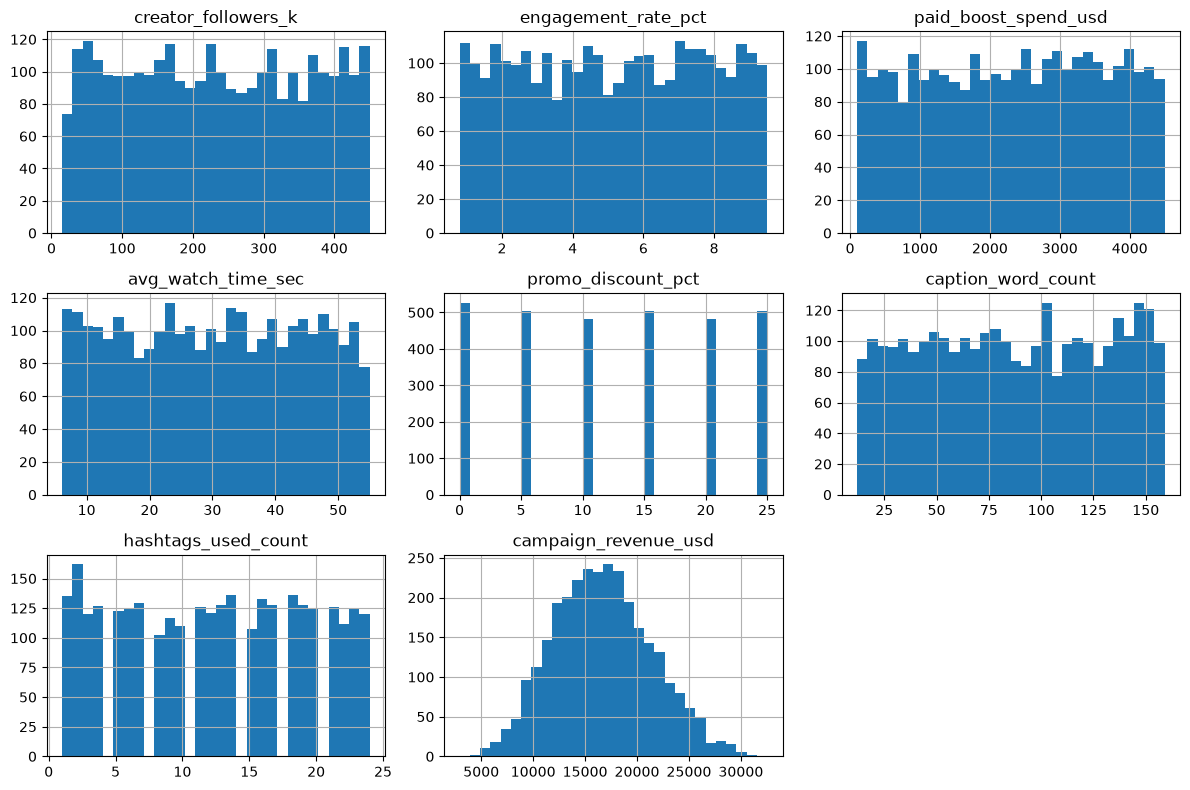

In [20]:
# Distribution
df.hist(
    figsize=(12, 8), 
    bins=30,
    )
plt.tight_layout()
plt.savefig(f"../figures/distribution/data_distribution.png", dpi=600, bbox_inches='tight')
plt.show()

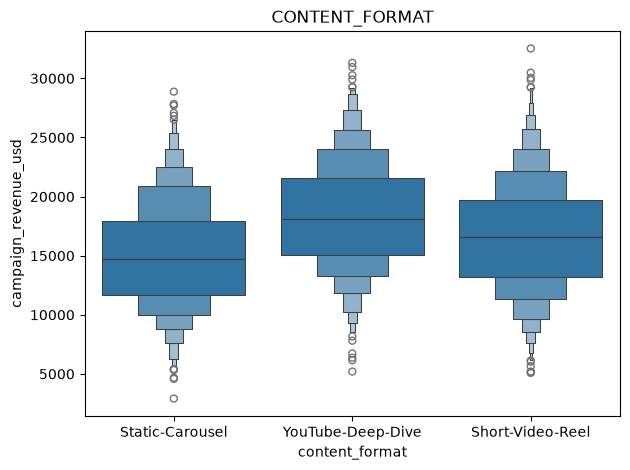

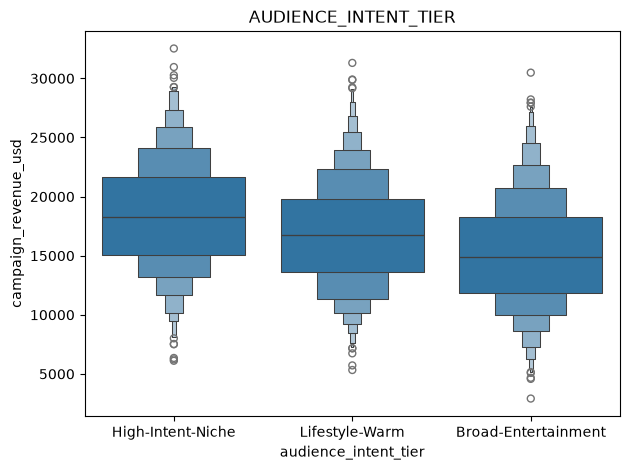

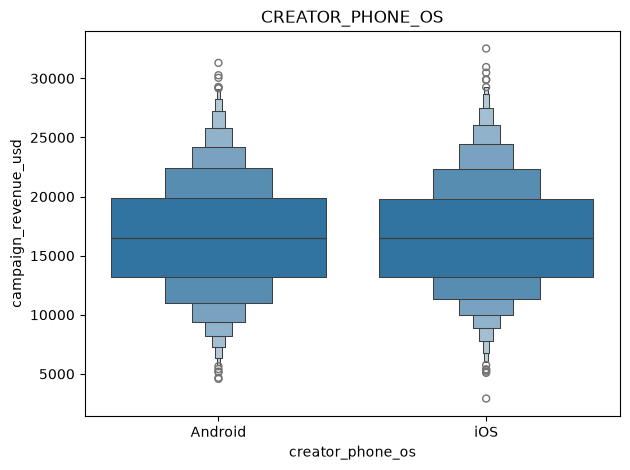

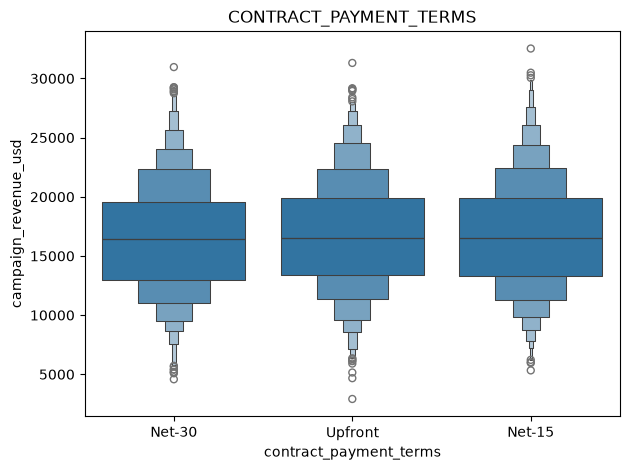

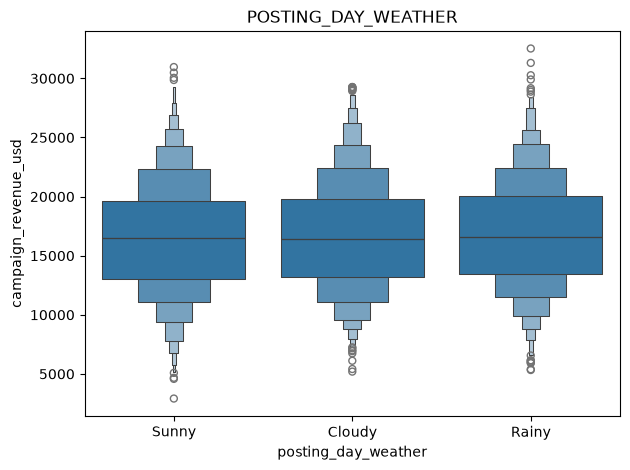

In [29]:
# Distribution for categorical features
cat_cols = df.select_dtypes(include=['str', 'object']).columns.tolist()
for col in cat_cols:
    sns.boxenplot(x=col, y='campaign_revenue_usd', data=df)
    plt.title(col.upper())
    plt.tight_layout()
    plt.savefig(f"../figures/distribution/cat_{col}.png", dpi=600, bbox_inches='tight')
    plt.show()